<a href="https://colab.research.google.com/github/krigly/Project_ML/blob/main/Project_4_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [4]:
df['balance'].isnull().sum()

np.int64(25)

### Задание 2

In [5]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
df['job'].value_counts()

,count
job,
management,2566
blue-collar,1944
technician,1823
admin.,1334
services,923
retired,778
self-employed,405
student,360
unemployed,357


### Задание 3

In [6]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'].head()

,balance
0,"2 343,00 $"
1,"45,00 $"
2,"1 270,00 $"
3,"2 476,00 $"
4,"184,00 $"


In [7]:
df['balance'] = pd.to_numeric(df['balance'].str[:-2].str.replace(',', '.').str.replace(' ', ''), errors='coerce')

In [8]:
df['balance'].head()

,balance
0,2343.0
1,45.0
2,1270.0
3,2476.0
4,184.0


In [9]:
df['balance'].mean()

np.float64(1529.1290293615875)

### Задание 4

In [10]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
df['balance'] = df['balance'].fillna(df['balance'].median())

In [11]:
df['balance'].mean()

np.float64(1526.9360329690019)

### Задание 5

In [12]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения

df['education'] = df['education'].replace('unknown', df['education'].mode()[0])
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])

print(df['education'].value_counts())
print(df['job'].value_counts())

education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64
job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
Name: count, dtype: int64


In [13]:
df[(df['job'] == df['job'].mode()[0]) & (df['education'] == df['education'].mode()[0])]['balance'].mean()

np.float64(1598.8829787234042)

### Задание 6

In [14]:
# удалите все выбросы для признака balance
def delete_emissions(column, lower_limit, upper_limit):
  return df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

In [15]:
iqr = df['balance'].quantile(0.75) - df['balance'].quantile(0.25)

lower_l = df['balance'].quantile(0.25) - 1.5*iqr
upper_l = df['balance'].quantile(0.75) + 1.5*iqr

print(lower_l, upper_l)

-2241.0 4063.0


In [16]:
df_clean = delete_emissions('balance', lower_l, upper_l)
df_clean.shape[0]

10105

In [17]:
df = df_clean.copy()

## Часть 2:  Разведывательный анализ

### Задание 1

In [18]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
def graphic_class(column):
  df_clean[column].value_counts().plot(kind='bar', color=['blue', 'orange'])
  plt.title('Соотношение классов')
  plt.xlabel(column)
  plt.ylabel('Количество')
  plt.show()

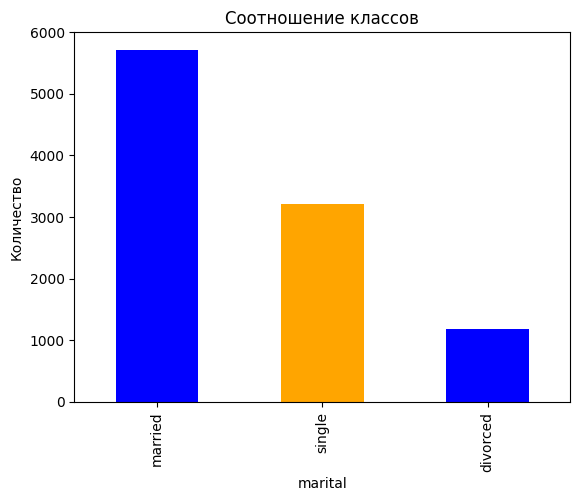

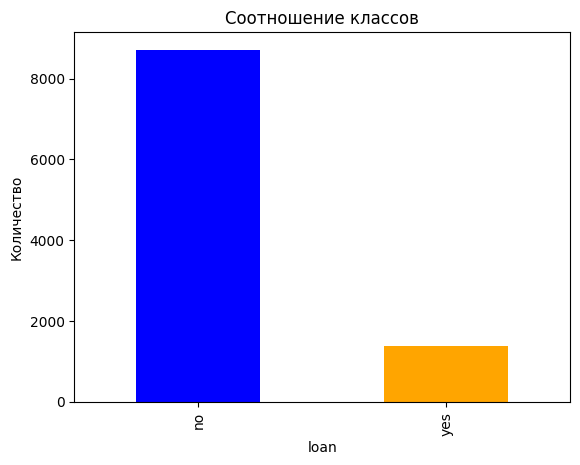

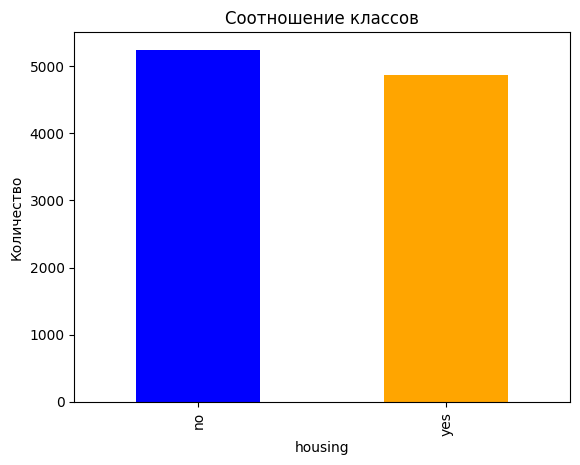

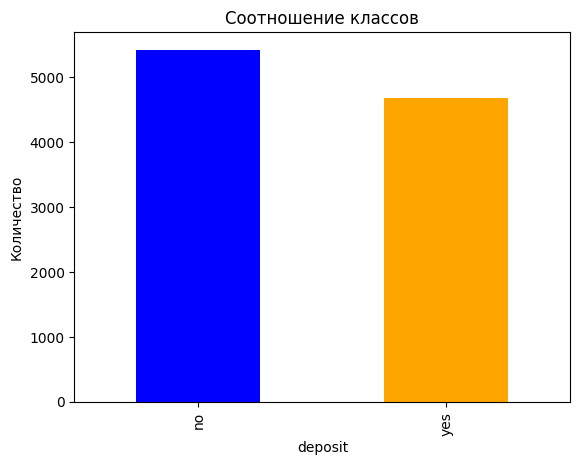

In [19]:
graphic_class('marital')
graphic_class('loan')
graphic_class('housing')
graphic_class('deposit')

### Задания 2 и 3

In [20]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
df_clean.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


Средний возраст клиентов - 41 год, большинство в возрасте 32–48 лет.

Средний баланс - 808 , медиана - 445  (распределение скошено вправо). Есть клиенты с отрицательным балансом (до -2049 ).

Средняя длительность разговора - 369 секунд (около 6 минут), 25–75% звонков длятся 2–8 минут.

Обычно клиентов контактируют 1–3 раза, максимум - 43 раза.

У большинства клиентов нет прошлых контактов (pdays = -1, previous = 0).

Максимальный баланс после очистки - 4063  (крупных выбросов нет).

### Задания 4 и 5

In [21]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты

cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome', 'deposit']
for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())
    print(f"\nВ процентах:")
    print(df[col].value_counts(normalize=True).round(3) * 100)


=== JOB ===
job
management       2315
blue-collar      1807
technician       1638
admin.           1246
services          868
retired           663
self-employed     358
unemployed        332
student           326
entrepreneur      300
housemaid         252
Name: count, dtype: int64

В процентах:
job
management       22.9
blue-collar      17.9
technician       16.2
admin.           12.3
services          8.6
retired           6.6
self-employed     3.5
unemployed        3.3
student           3.2
entrepreneur      3.0
housemaid         2.5
Name: proportion, dtype: float64

=== MARITAL ===
marital
married     5715
single      3213
divorced    1177
Name: count, dtype: int64

В процентах:
marital
married     56.6
single      31.8
divorced    11.6
Name: proportion, dtype: float64

=== EDUCATION ===
education
secondary    5517
tertiary     3239
primary      1349
Name: count, dtype: int64

В процентах:
education
secondary    54.6
tertiary     32.1
primary      13.3
Name: proportion, dtype: fl

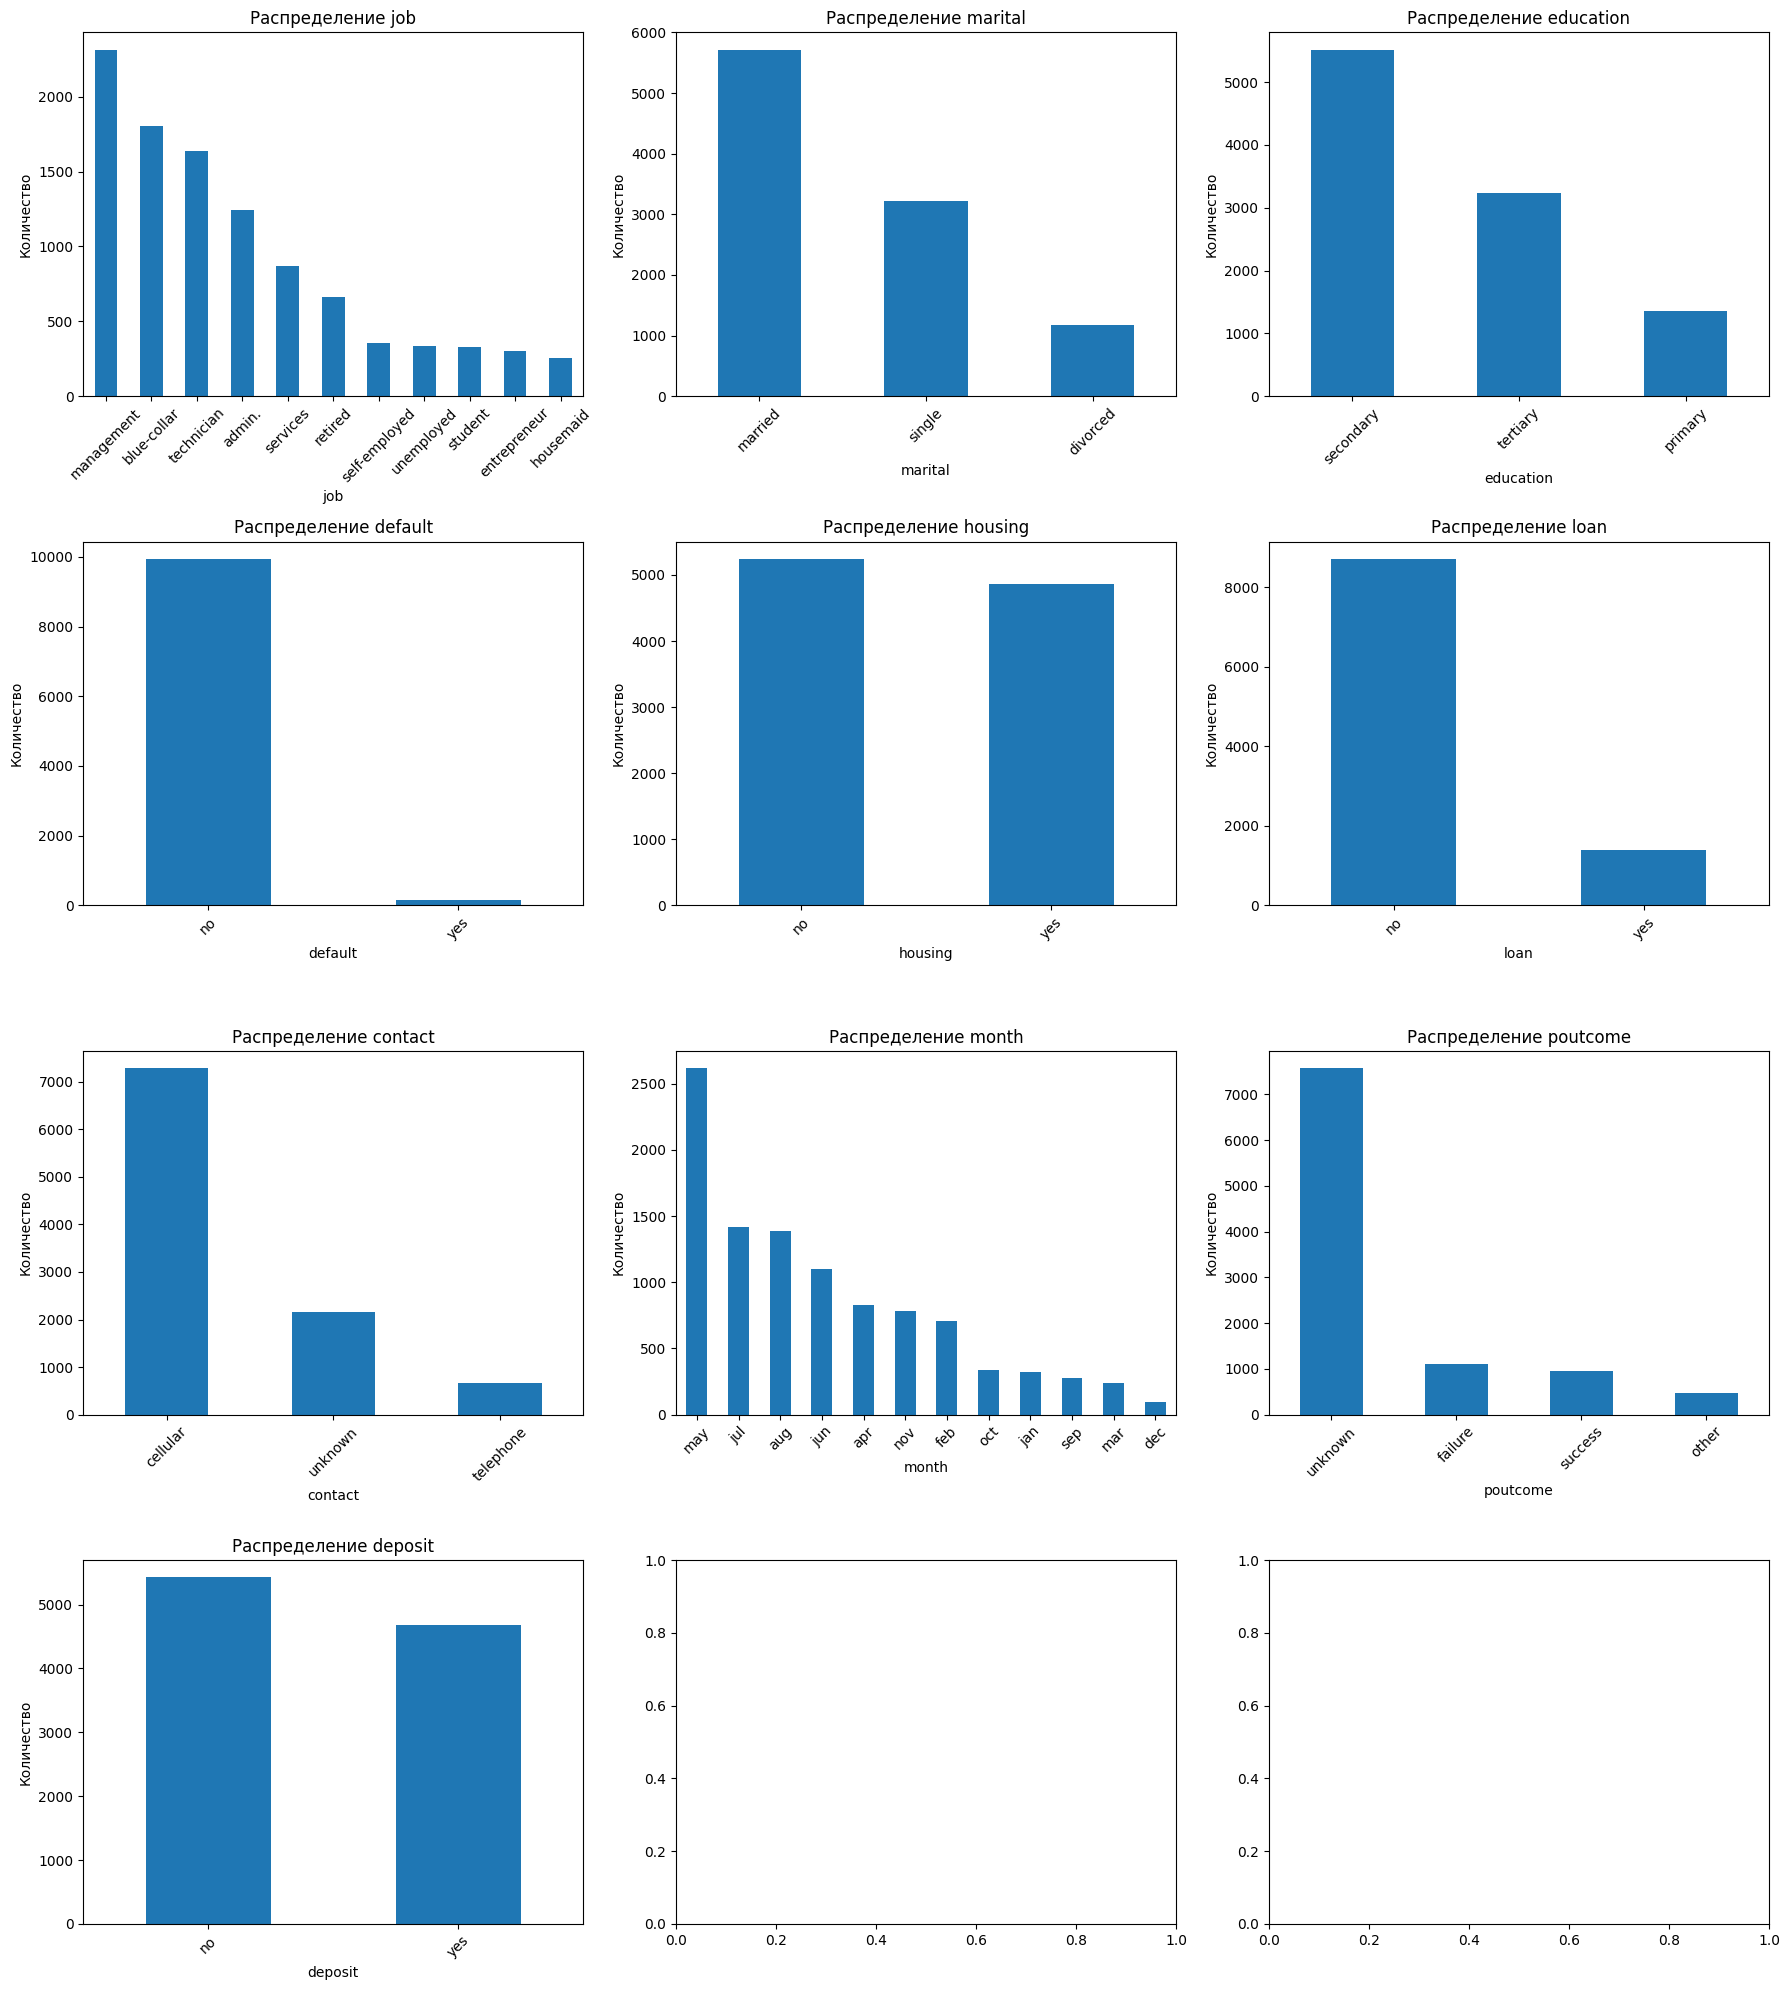

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Задание 6

In [23]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
cross = pd.crosstab(df['poutcome'], df['deposit'], normalize='index')*100
cross['success_rate'] = cross['yes']
print(cross.sort_values('success_rate', ascending=False))

deposit          no        yes  success_rate
poutcome                                    
success    8.888889  91.111111     91.111111
other     44.906445  55.093555     55.093555
failure   50.676285  49.323715     49.323715
unknown   60.264201  39.735799     39.735799


### Задание 7

In [24]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
df[df['deposit'] == 'no']['month'].value_counts()

,count
month,
may,1776
jul,836
aug,775
jun,606
nov,456
feb,323
apr,317
jan,194
oct,62


### Задание 8

In [25]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
bins = [0, 30, 40, 50, 60, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [26]:
age_deposit = pd.crosstab(df['age_group'], df['deposit'], normalize='index') * 100
print(age_deposit.sort_values('yes', ascending=False))

deposit           no        yes
age_group                      
60+        24.042879  75.957121
<30        40.824742  59.175258
30-40      56.677607  43.322393
50-60      59.492140  40.507860
40-50      60.621327  39.378673


### Задания 9 и 10

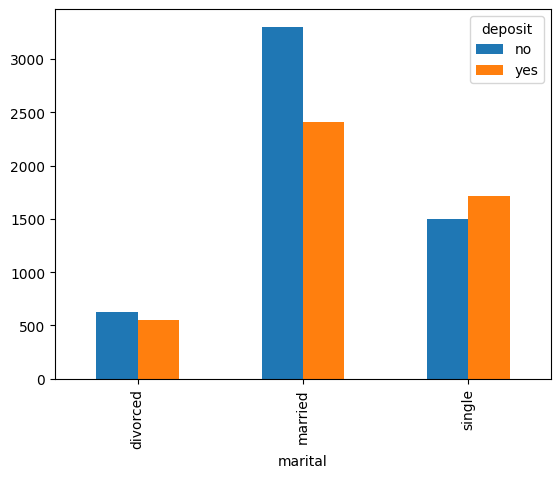

In [27]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
pd.crosstab(df['marital'], df['deposit']).plot(kind='bar')
plt.show()


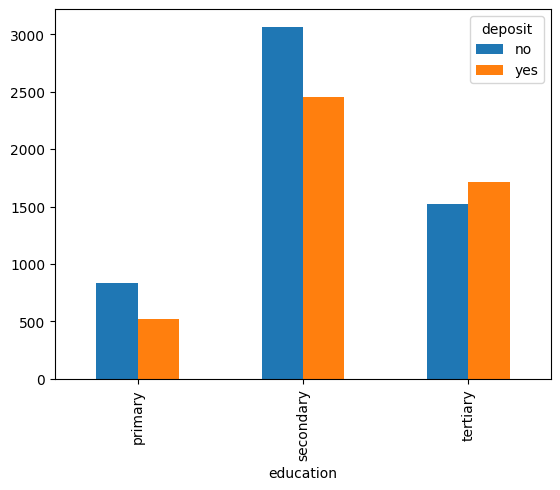

In [28]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
pd.crosstab(df['education'], df['deposit']).plot(kind='bar')
plt.show()

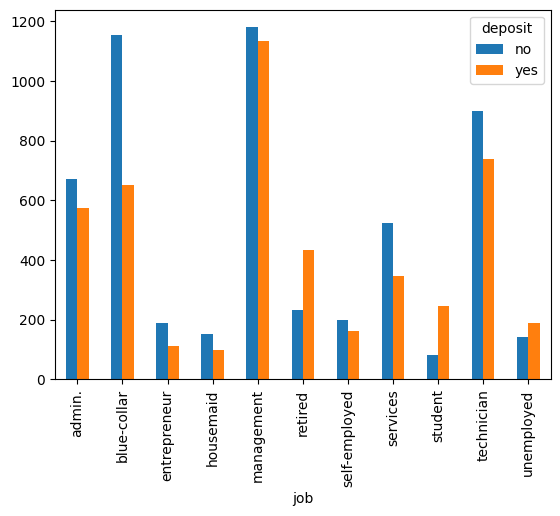

In [29]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
pd.crosstab(df['job'], df['deposit']).plot(kind='bar')
plt.show()

### Задание 11

In [30]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
deposit_yes = df[df['deposit'] == 'yes']
pivot = pd.crosstab(deposit_yes['education'], deposit_yes['marital'])
print(pivot)

marital    divorced  married  single
education                           
primary          96      339      82
secondary       283     1289     879
tertiary        174      784     755


## Часть 3: преобразование данных

### Задание 1

In [31]:
# преобразуйте уровни образования
encoder1 = LabelEncoder()
df['education'] = encoder1.fit_transform(df['education'])


df['education'].sum()

np.int64(11995)

In [32]:
encoder2 = LabelEncoder()
df['age_group'] = encoder2.fit_transform(df['age_group'])

### Задания 2 и 3

In [33]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,59,admin.,married,1,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,2
1,56,admin.,married,1,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,2
2,41,technician,married,1,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,1
3,55,services,married,1,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,2
4,54,admin.,married,2,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes,2


In [34]:
# преобразуйте бинарные переменные в представление из нулей и единиц

binary_cols = ['default', 'housing', 'loan', 'deposit']

for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

In [35]:
df['deposit'].std()

0.4986712532451993

In [36]:
df['default'].mean() + df['housing'].mean() + df['loan'].mean()

np.float64(0.6354280059376547)

### Задание 4

In [37]:
# создайте дамми-переменные
labels = ['job',
'marital',
'contact',
'month',
'poutcome']

dummies = pd.get_dummies(df[labels])
df = pd.concat([df, dummies], axis=1)

In [38]:
df.shape[1]

51

In [39]:
df.drop(labels, axis=1, inplace=True)

### Задания 5 и 6

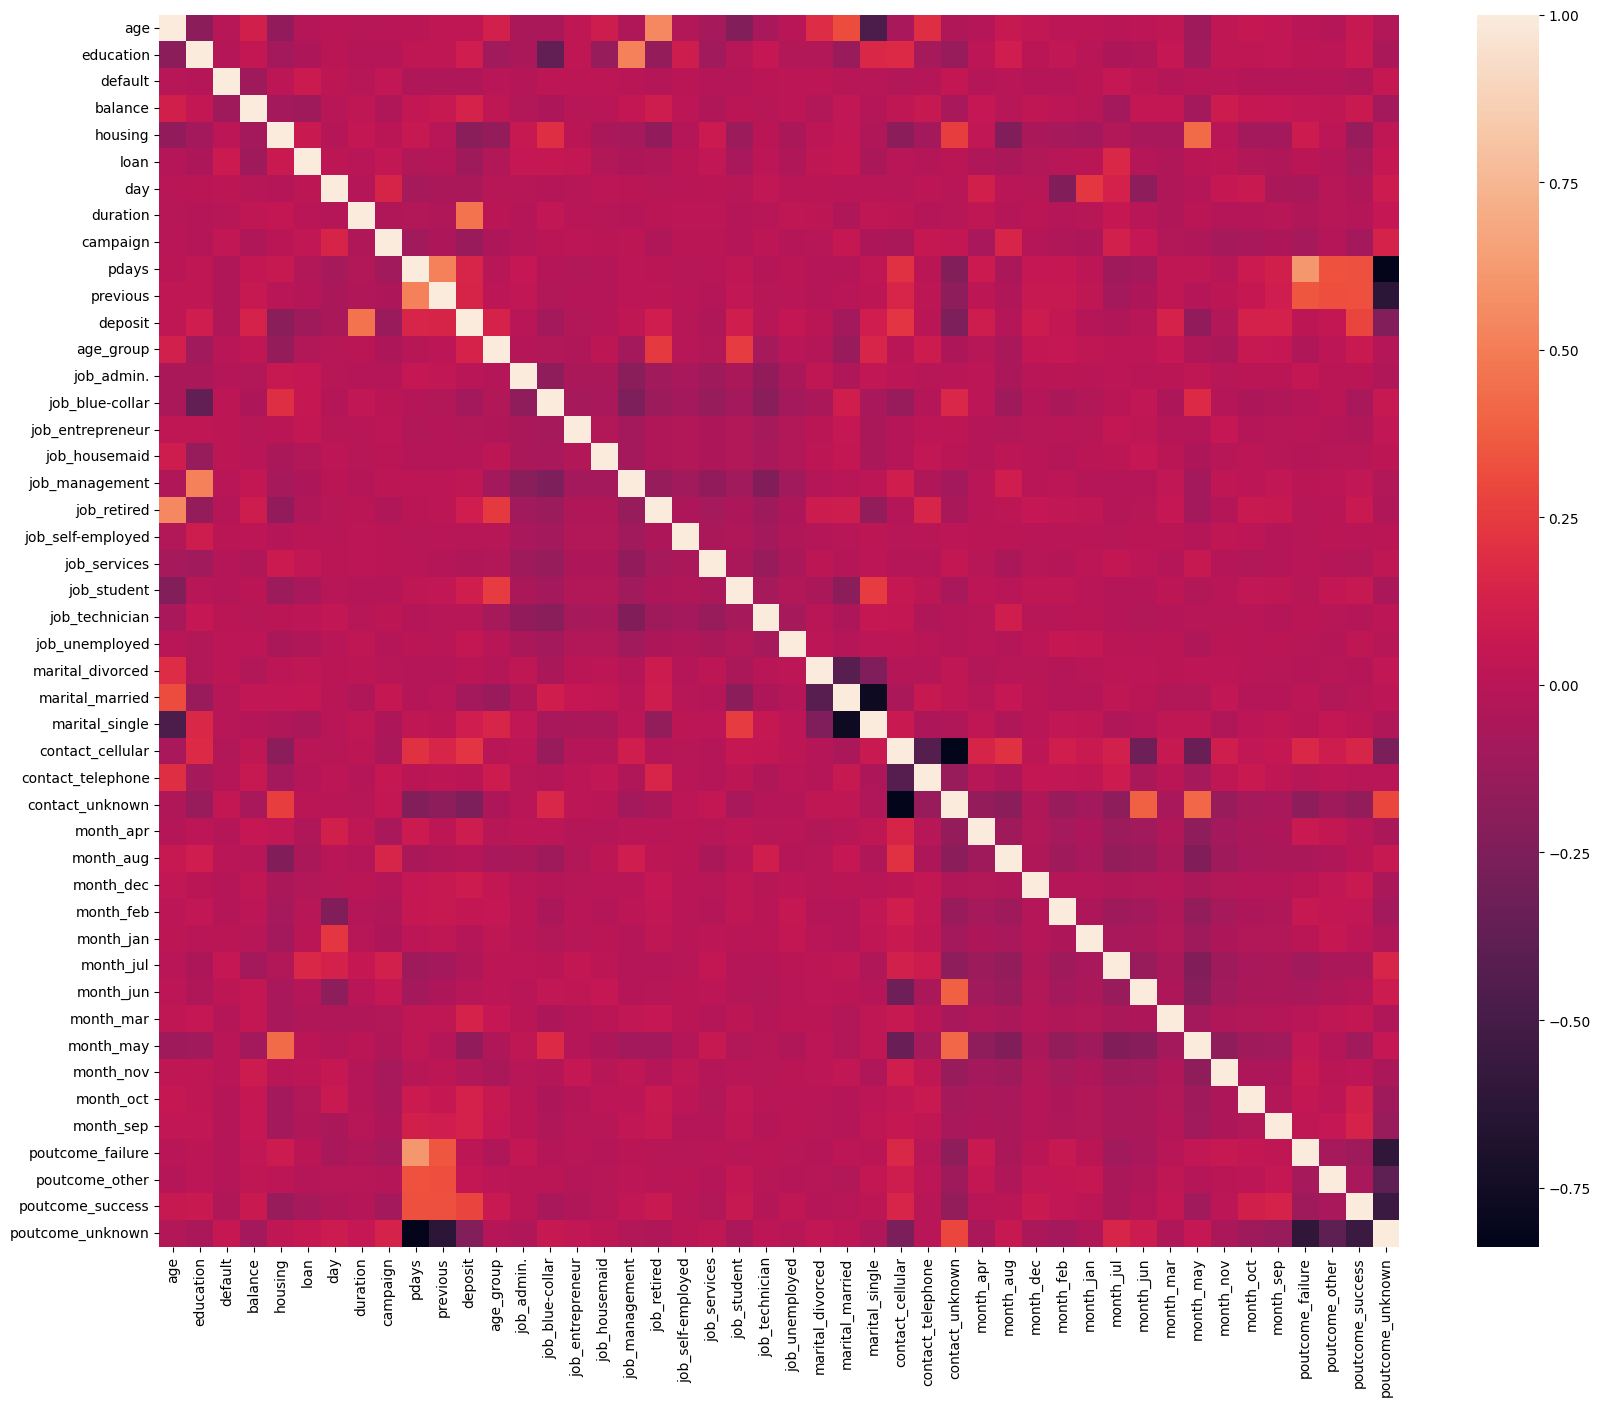

In [40]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.show()

In [41]:
df_corr = df.corr(numeric_only=True)
df_corr[df_corr > 0.9].stack()

,,0
age,age,1.0
education,education,1.0
default,default,1.0
balance,balance,1.0
housing,housing,1.0
loan,loan,1.0
day,day,1.0
duration,duration,1.0
campaign,campaign,1.0
pdays,pdays,1.0


### Задания 7 и 8

In [42]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [43]:
# рассчитайте необходимые показатели
X_test.shape[0]

3335

In [44]:
y_test.mean()

np.float64(0.46326836581709147)

### Задание 9

In [45]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector = SelectKBest(f_classif, k=15)
selector.fit(X_train, y_train)

selector.get_feature_names_out()

array(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_group', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

In [46]:
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

### Задание 10

In [47]:
# нормализуйте данные с помощью minmaxsxaler

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
X_test[:, 0].mean()

np.float64(0.46823674223097866)

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [50]:
# обучите логистическую регрессию и рассчитайте метрики качества
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    solver='sag',
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='sag')

In [51]:
from sklearn.metrics import accuracy_score

accuracy_score(lr.predict(X_test), y_test)

0.8047976011994002

### Задания 2,3,4

In [52]:
# обучите решающие деревья, настройте максимальную глубину
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

st = DecisionTreeClassifier(
    random_state=42,
    criterion='entropy'
)

st.fit(X_train, y_train)

print(classification_report(y_test, st.predict(X_test)))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77      1790
           1       0.74      0.71      0.72      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.74      0.75      3335
weighted avg       0.75      0.75      0.75      3335



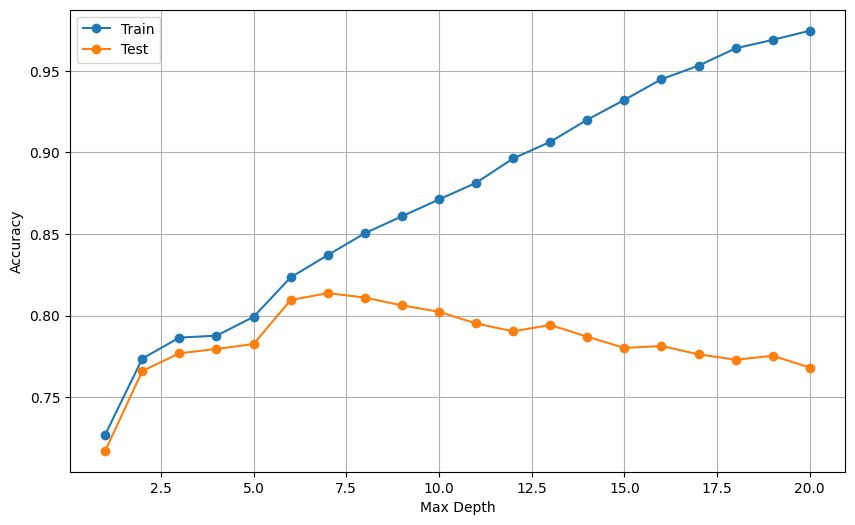

Оптимальная глубина: 7
Test accuracy: 0.8138


In [53]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Список глубин для проверки
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))

    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train', marker='o')
plt.plot(depths, test_scores, label='Test', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Поиск оптимальной глубины (без переобучения)
best_depth = None
best_test_acc = 0

for i, depth in enumerate(depths):
    if test_scores[i] > best_test_acc:
        best_test_acc = test_scores[i]
        best_depth = depth
    # Если train растёт, а test перестал расти — стоп
    elif i > 0 and train_scores[i] > train_scores[i-1] and test_scores[i] <= test_scores[i-1]:
        break

print(f"Оптимальная глубина: {best_depth}")
print(f"Test accuracy: {best_test_acc:.4f}")

In [54]:
# обучите решающие деревья, настройте максимальную глубину
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

st = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

st.fit(X_train, y_train)

print(classification_report(y_test, st.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1790
           1       0.80      0.78      0.79      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.81      0.81      0.81      3335



### Задание 5

In [55]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV

grid_param = {'min_samples_split': [2, 5, 7, 10],
'max_depth':[3,5,7]}

lr_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       grid_param, cv=2, scoring='f1', n_jobs=1)
lr_grid.fit(X_train, y_train)

GridSearchCV(cv=2, estimator=DecisionTreeClassifier(random_state=42), n_jobs=1,
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 7, 10]},
             scoring='f1')

In [56]:
print(f"GridSearchCV - лучшие параметры: {lr_grid.best_params_}")
print(f"GridSearchCV - лучший F1 (CV): {lr_grid.best_score_:.4f}")

GridSearchCV - лучшие параметры: {'max_depth': 7, 'min_samples_split': 2}
GridSearchCV - лучший F1 (CV): 0.7880


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [57]:
# обучите на ваших данных случайный лес
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

rf = RandomForestClassifier(
    n_estimators = 100,
    criterion = 'gini',
    min_samples_leaf = 5,
    max_depth = 10,
    random_state = 42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.8284857571214392
0.8349514563106796


### Задания 2 и 3

In [58]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

In [59]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1731
           1       0.83      0.80      0.82      1604

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



In [60]:
print(classification_report(rf.predict(X_test), y_test))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1728
           1       0.83      0.80      0.82      1607

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 4

In [61]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('dt', st),
    ('lr', lr),
    ('gb', gb)
]


stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)

In [62]:
print(classification_report(y_pred_stack, y_test))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1774
           1       0.82      0.81      0.81      1561

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335



### Задание 5

In [67]:
selected_features = X.columns[selector.get_support()].tolist()

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("=== ВАЖНОСТЬ ПРИЗНАКОВ (Gradient Boosting) ===")
print(feature_importance)

print("\n=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ===")
print(feature_importance.head(10))

=== ВАЖНОСТЬ ПРИЗНАКОВ (Gradient Boosting) ===
             feature  importance
2           duration    0.501539
13  poutcome_success    0.116203
8    contact_unknown    0.073963
0            balance    0.060586
4              pdays    0.055109
1            housing    0.046875
6          age_group    0.041819
9          month_mar    0.026098
11         month_oct    0.019117
3           campaign    0.017313
10         month_may    0.013990
12         month_sep    0.013426
5           previous    0.009082
7   contact_cellular    0.004502
14  poutcome_unknown    0.000377

=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ===
             feature  importance
2           duration    0.501539
13  poutcome_success    0.116203
8    contact_unknown    0.073963
0            balance    0.060586
4              pdays    0.055109
1            housing    0.046875
6          age_group    0.041819
9          month_mar    0.026098
11         month_oct    0.019117
3           campaign    0.017313


### Задания 6,7,8

In [68]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.8 MB/s eta 0:00:00


In [69]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print("="*50)
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"n_estimators: {study.best_params['n_estimators']}")
print(f"max_depth: {study.best_params['max_depth']}")
print(f"min_samples_leaf: {study.best_params['min_samples_leaf']}")
print(f"Лучший F1 (CV): {study.best_value:.4f}")
print("="*50)

[I 2026-06-18 15:00:49,129] A new study created in memory with name: no-name-6017f785-81ae-4387-99a1-055c385c5548


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-18 15:00:53,700] Trial 0 finished with value: 0.8211619366166307 and parameters: {'n_estimators': 137, 'max_depth': 29, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8211619366166307.
[I 2026-06-18 15:01:02,534] Trial 1 finished with value: 0.8284032300694613 and parameters: {'n_estimators': 160, 'max_depth': 13, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8284032300694613.
[I 2026-06-18 15:01:07,831] Trial 2 finished with value: 0.8204064935952029 and parameters: {'n_estimators': 105, 'max_depth': 28, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.8284032300694613.
[I 2026-06-18 15:01:14,146] Trial 3 finished with value: 0.8201916270515597 and parameters: {'n_estimators': 171, 'max_depth': 10, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.8284032300694613.
[I 2026-06-18 15:01:23,626] Trial 4 finished with value: 0.8291356385639264 and parameters: {'n_estimators': 184, 'max_depth': 14, 'min_samples_leaf': 3}. Best is trial 4 with value: 0.82